In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 7, 'axis': 'x'}

In [3]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test7/rolling_x
['reference', 'info.json', 'target']


In [4]:
TARGET_VAR = 'pitch'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [25, 200], 'static': [200, 999999999]}
[200, 999999999]
[25, 200]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,pitch,wz,time,wy,la_pos_mon_d,wx,az,ay,q1,sample_time,q0,q2,q3,yaw,ax,roll
0,-0.000118,0.000105,2.384186e-07,-0.000020,0.0,0.000383,3.403,-8.814,0.000109,705000000.0,1.0000,-0.000060,-0.000054,-0.000107,2.554,0.000217
1,-0.000133,0.000060,8.821797e-02,-0.000206,0.0,0.000273,3.403,-8.813,0.000120,805000000.0,1.0000,-0.000067,-0.000057,-0.000111,2.553,0.000237
2,-0.000149,-0.000040,1.923132e-01,-0.000116,0.0,0.000448,3.403,-8.813,0.000136,905000000.0,1.0000,-0.000076,-0.000065,-0.000130,2.554,0.000271
3,-0.000164,-0.000110,2.901497e-01,-0.000013,0.0,0.000268,3.403,-8.813,0.000148,5000000.0,1.0000,-0.000083,-0.000064,-0.000126,2.554,0.000294
4,-0.000179,-0.000023,3.944306e-01,-0.000098,0.0,0.000199,3.403,-8.813,0.000161,105000000.0,1.0000,-0.000090,-0.000067,-0.000130,2.554,0.000320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,0.408200,0.000050,3.495178e+02,-0.002414,10.0,0.001106,3.375,-8.817,0.737500,205000000.0,0.3690,-0.350000,-0.444200,-1.167000,2.576,1.942000
3496,0.408300,-0.000043,3.496156e+02,-0.002543,10.0,0.001280,3.375,-8.817,0.737500,305000000.0,0.3689,-0.350100,-0.444300,-1.168000,2.576,1.942000
3497,0.408400,0.000104,3.497143e+02,-0.002521,10.0,0.001523,3.375,-8.817,0.737500,405000000.0,0.3688,-0.350200,-0.444400,-1.168000,2.576,1.942000
3498,0.408400,-0.000036,3.498202e+02,-0.002541,10.0,0.001623,3.375,-8.817,0.737500,505000000.0,0.3687,-0.350300,-0.444400,-1.168000,2.576,1.942000


- Convertendo pra radianos

In [6]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,pitch,wz,time,wy,la_pos_mon_d,wx,az,ay,q1,sample_time,q0,q2,q3,yaw,ax,roll
0,-0.006772,0.005987,2.384186e-07,-0.001163,0.0,0.021967,3.403,-8.814,0.000109,705000000.0,1.0000,-0.000060,-0.000054,-0.006119,2.554,0.012456
1,-0.007649,0.003447,8.821797e-02,-0.011826,0.0,0.015659,3.403,-8.813,0.000120,805000000.0,1.0000,-0.000067,-0.000057,-0.006337,2.553,0.013550
2,-0.008520,-0.002273,1.923132e-01,-0.006635,0.0,0.025663,3.403,-8.813,0.000136,905000000.0,1.0000,-0.000076,-0.000065,-0.007431,2.554,0.015516
3,-0.009397,-0.006303,2.901497e-01,-0.000720,0.0,0.015344,3.403,-8.813,0.000148,5000000.0,1.0000,-0.000083,-0.000064,-0.007214,2.554,0.016828
4,-0.010267,-0.001340,3.944306e-01,-0.005608,0.0,0.011379,3.403,-8.813,0.000161,105000000.0,1.0000,-0.000090,-0.000067,-0.007431,2.554,0.018358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,23.388137,0.002860,3.495178e+02,-0.138312,10.0,0.063369,3.375,-8.817,0.737500,205000000.0,0.3690,-0.350000,-0.444200,-66.864175,2.576,111.268404
3496,23.393867,-0.002476,3.496156e+02,-0.145703,10.0,0.073339,3.375,-8.817,0.737500,305000000.0,0.3689,-0.350100,-0.444300,-66.921470,2.576,111.268404
3497,23.399596,0.005964,3.497143e+02,-0.144443,10.0,0.087261,3.375,-8.817,0.737500,405000000.0,0.3688,-0.350200,-0.444400,-66.921470,2.576,111.268404
3498,23.399596,-0.002044,3.498202e+02,-0.145589,10.0,0.092991,3.375,-8.817,0.737500,505000000.0,0.3687,-0.350300,-0.444400,-66.921470,2.576,111.268404


In [7]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,pitch,wz,time,wy,la_pos_mon_d,wx,az,ay,q1,sample_time,q0,q2,q3,yaw,ax,roll


# VISUALIZAÇÃO DE VARIÁVEIS

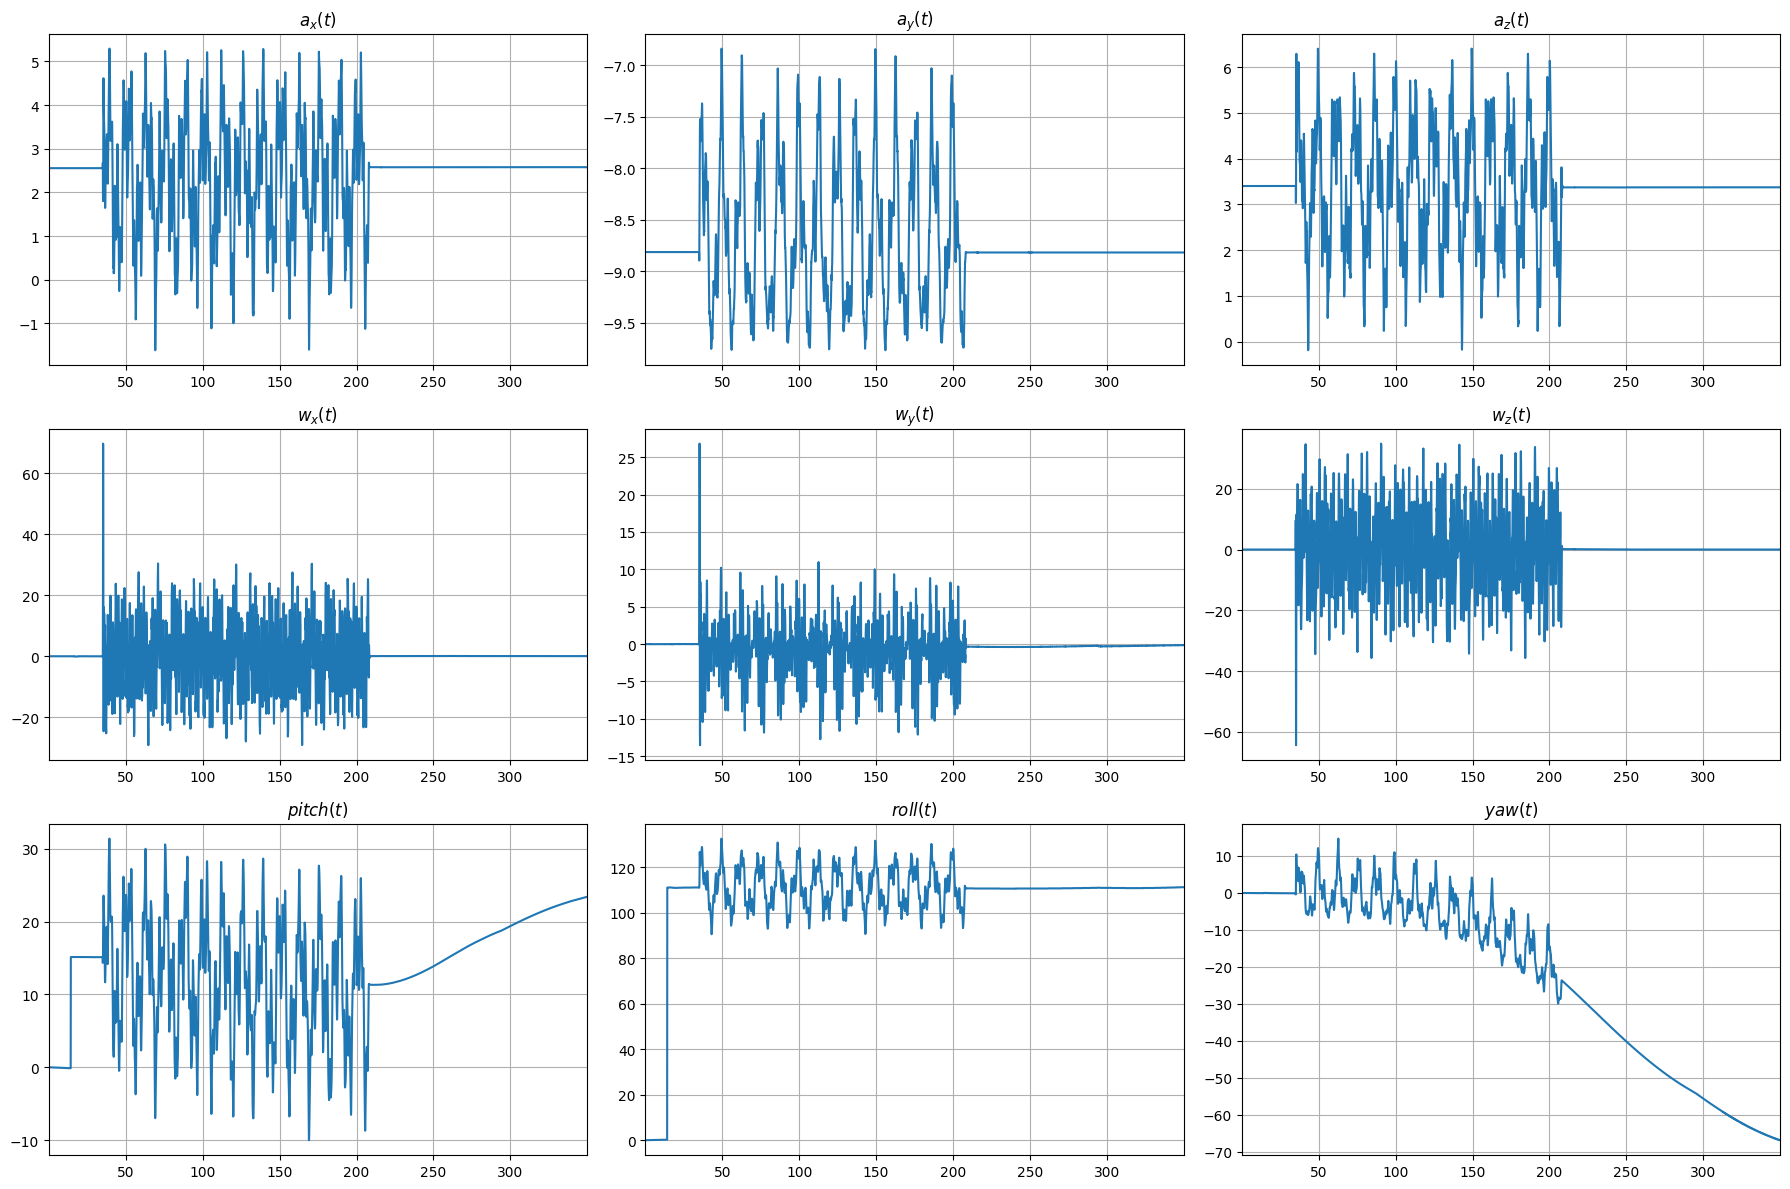

In [8]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

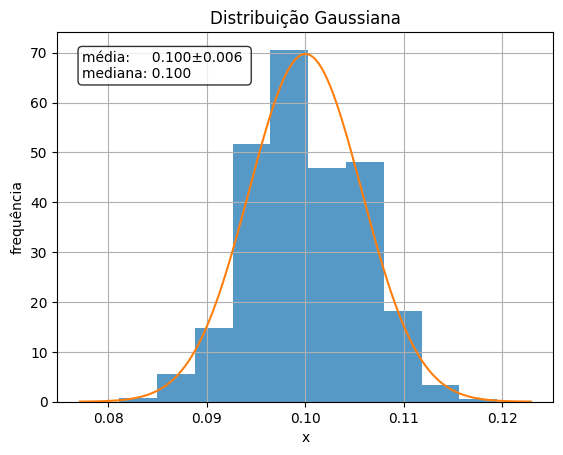

,time,pitch,wz,wy,la_pos_mon_d,wx,az,ay,q1,sample_time,q0,q2,q3,yaw,ax,roll
0,0.0,-0.006772,0.005987,-0.001163,0.0,0.021967,3.403,-8.814,0.000109,705000000.0,1.0000,-0.000060,-0.000054,-0.006119,2.554,0.012456
1,0.1,-0.007649,0.003447,-0.011826,0.0,0.015659,3.403,-8.813,0.000120,805000000.0,1.0000,-0.000067,-0.000057,-0.006337,2.553,0.013550
2,0.2,-0.008520,-0.002273,-0.006635,0.0,0.025663,3.403,-8.813,0.000136,905000000.0,1.0000,-0.000076,-0.000065,-0.007431,2.554,0.015516
3,0.3,-0.009397,-0.006303,-0.000720,0.0,0.015344,3.403,-8.813,0.000148,5000000.0,1.0000,-0.000083,-0.000064,-0.007214,2.554,0.016828
4,0.4,-0.010267,-0.001340,-0.005608,0.0,0.011379,3.403,-8.813,0.000161,105000000.0,1.0000,-0.000090,-0.000067,-0.007431,2.554,0.018358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496,349.6,23.388137,0.002860,-0.138312,10.0,0.063369,3.375,-8.817,0.737500,205000000.0,0.3690,-0.350000,-0.444200,-66.864175,2.576,111.268404
3497,349.7,23.393867,-0.002476,-0.145703,10.0,0.073339,3.375,-8.817,0.737500,305000000.0,0.3689,-0.350100,-0.444300,-66.921470,2.576,111.268404
3498,349.8,23.399596,0.005964,-0.144443,10.0,0.087261,3.375,-8.817,0.737500,405000000.0,0.3688,-0.350200,-0.444400,-66.921470,2.576,111.268404
3499,349.9,23.399596,-0.002044,-0.145589,10.0,0.092991,3.375,-8.817,0.737500,505000000.0,0.3687,-0.350300,-0.444400,-66.921470,2.576,111.268404


In [9]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [10]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,pitch,wz,wy,la_pos_mon_d,wx,az,ay,q1,sample_time,q0,q2,q3,yaw,ax,roll,static
0,0.0,15.126086,0.000987,-0.011992,-0.2845,0.010285,3.403,-8.813,0.8174,705000000.0,0.5608,0.07407,-0.1088,-0.055720,2.554,111.096516,False
1,0.1,15.126086,0.020054,-0.002231,-0.2893,0.004733,3.403,-8.813,0.8174,805000000.0,0.5608,0.07406,-0.1088,-0.056173,2.553,111.096516,False
2,0.2,15.126086,0.004792,0.004034,-0.2941,0.011591,3.403,-8.813,0.8174,905000000.0,0.5608,0.07406,-0.1088,-0.055955,2.554,111.096516,False
3,0.3,15.126086,0.001441,-0.003922,-0.2989,0.018065,3.403,-8.813,0.8174,5000000.0,0.5608,0.07405,-0.1088,-0.056608,2.553,111.096516,False
4,0.4,15.126086,-0.009912,-0.003138,-0.3037,0.005427,3.403,-8.813,0.8174,105000000.0,0.5608,0.07405,-0.1088,-0.056826,2.554,111.096516,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,23.388137,0.002860,-0.138312,10.0000,0.063369,3.375,-8.817,0.7375,205000000.0,0.3690,-0.35000,-0.4442,-66.864175,2.576,111.268404,True
3247,324.6,23.393867,-0.002476,-0.145703,10.0000,0.073339,3.375,-8.817,0.7375,305000000.0,0.3689,-0.35010,-0.4443,-66.921470,2.576,111.268404,True
3248,324.7,23.399596,0.005964,-0.144443,10.0000,0.087261,3.375,-8.817,0.7375,405000000.0,0.3688,-0.35020,-0.4444,-66.921470,2.576,111.268404,True
3249,324.8,23.399596,-0.002044,-0.145589,10.0000,0.092991,3.375,-8.817,0.7375,505000000.0,0.3687,-0.35030,-0.4444,-66.921470,2.576,111.268404,True


# FILTRANDO POR VARIAVEL

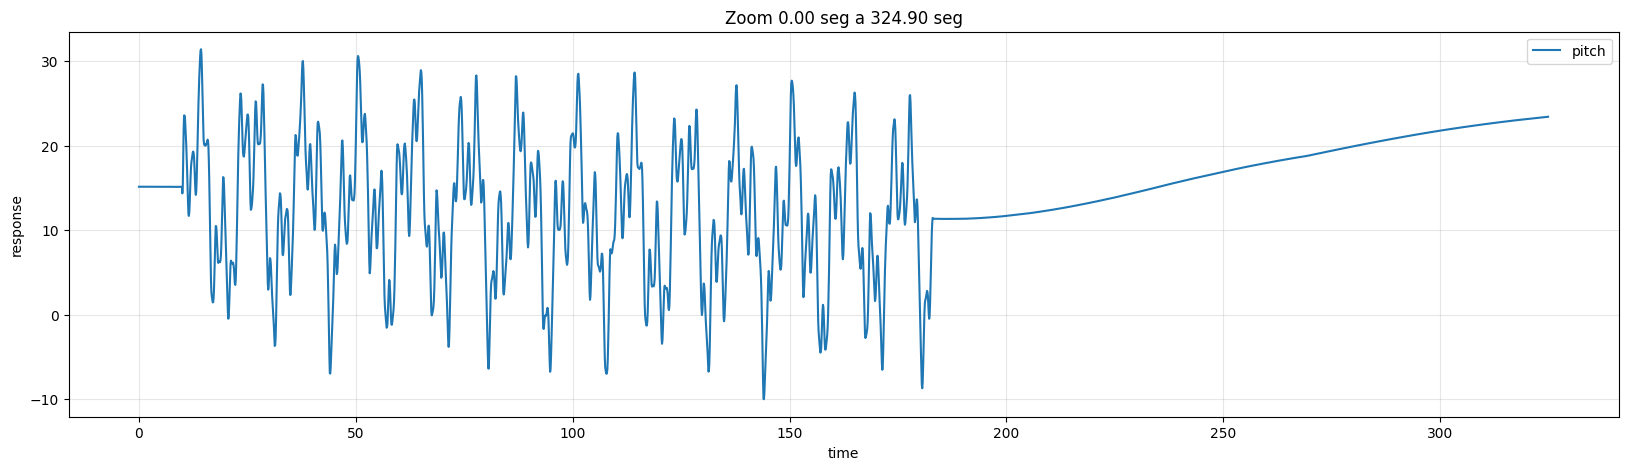

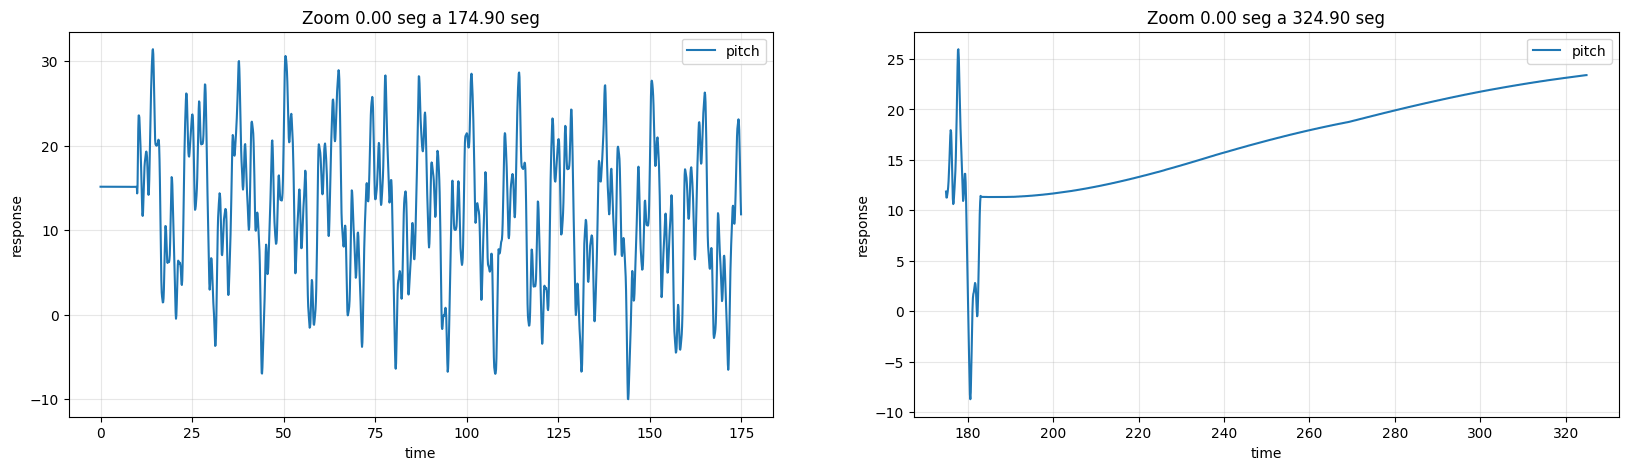

In [11]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [12]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_pitch,ref_wz,ref_wy,ref_la_pos_mon_d,ref_wx,ref_az,ref_ay,ref_q1,ref_sample_time,ref_q0,ref_q2,ref_q3,ref_yaw,ref_ax,ref_roll,static
0,0.0,15.126086,0.000987,-0.011992,-0.2845,0.010285,3.403,-8.813,0.8174,705000000.0,0.5608,0.07407,-0.1088,-0.055720,2.554,111.096516,False
1,0.1,15.126086,0.020054,-0.002231,-0.2893,0.004733,3.403,-8.813,0.8174,805000000.0,0.5608,0.07406,-0.1088,-0.056173,2.553,111.096516,False
2,0.2,15.126086,0.004792,0.004034,-0.2941,0.011591,3.403,-8.813,0.8174,905000000.0,0.5608,0.07406,-0.1088,-0.055955,2.554,111.096516,False
3,0.3,15.126086,0.001441,-0.003922,-0.2989,0.018065,3.403,-8.813,0.8174,5000000.0,0.5608,0.07405,-0.1088,-0.056608,2.553,111.096516,False
4,0.4,15.126086,-0.009912,-0.003138,-0.3037,0.005427,3.403,-8.813,0.8174,105000000.0,0.5608,0.07405,-0.1088,-0.056826,2.554,111.096516,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,23.388137,0.002860,-0.138312,10.0000,0.063369,3.375,-8.817,0.7375,205000000.0,0.3690,-0.35000,-0.4442,-66.864175,2.576,111.268404,True
3247,324.6,23.393867,-0.002476,-0.145703,10.0000,0.073339,3.375,-8.817,0.7375,305000000.0,0.3689,-0.35010,-0.4443,-66.921470,2.576,111.268404,True
3248,324.7,23.399596,0.005964,-0.144443,10.0000,0.087261,3.375,-8.817,0.7375,405000000.0,0.3688,-0.35020,-0.4444,-66.921470,2.576,111.268404,True
3249,324.8,23.399596,-0.002044,-0.145589,10.0000,0.092991,3.375,-8.817,0.7375,505000000.0,0.3687,-0.35030,-0.4444,-66.921470,2.576,111.268404,True


In [13]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)